In [5]:
#Import all libraries 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Load the files 
Netflix_stock_action = pd.read_csv("Netflix_stock_action.csv")
Netflix_stock_history = pd.read_csv("Netflix_stock_history_clean.csv")
Netflix_stock_spilts = pd.read_csv("Netflix_stock_action_clean.csv")
Netflix_stock_info = pd.read_csv("Netflix_stock_action_clean.csv")

In [4]:
#Basic Inspection
print(Netflix_stock_history.head())
print(Netflix_stock_history.shape)
print(Netflix_stock_history.info())
print(Netflix_stock_history.describe())

         Date  Adj Close     Close      High       Low      Open      Volume  \
0  2002-05-23   0.119643  0.119643  0.124286  0.114571  0.115643  1047900000   
1  2002-05-24   0.121000  0.121000  0.122500  0.119714  0.121429   111048000   
2  2002-05-28   0.115714  0.115714  0.123214  0.115714  0.121357    66094000   
3  2002-05-29   0.110357  0.110357  0.116429  0.108571  0.116429    67578000   
4  2002-05-30   0.107143  0.107143  0.110786  0.107143  0.110786   101542000   

   Daily_Return  Daily_Range  Open_Close_Change  Year  Month  Return_Outlier  
0           NaN     0.009715           0.004000  2002      5           False  
1      1.134205     0.002786          -0.000429  2002      5           False  
2     -4.368596     0.007500          -0.005643  2002      5           False  
3     -4.629515     0.007858          -0.006072  2002      5           False  
4     -2.912368     0.003643          -0.003643  2002      5           False  
(6010, 13)
<class 'pandas.core.frame.DataFram

In [8]:
#Mean, Median and Mode
numeric_cols = [
    "Open", "High", "Low",
    "Close", "Adj Close", "Volume"
]

print("MEAN")
print(Netflix_stock_history[numeric_cols].mean())

print("\nMEDIAN")
print(Netflix_stock_history[numeric_cols].median())

print("\nMODE")
print(Netflix_stock_history[numeric_cols].mode().iloc[0])

MEAN
Open         2.038428e+01
High         2.067515e+01
Low          2.008660e+01
Close        2.038895e+01
Adj Close    2.038895e+01
Volume       1.476884e+08
dtype: float64

MEDIAN
Open         5.245929e+00
High         5.332214e+00
Low          5.182572e+00
Close        5.237857e+00
Adj Close    5.237857e+00
Volume       9.056600e+07
dtype: float64

MODE
Open         3.171430e-01
High         3.285710e-01
Low          1.500000e-01
Close        1.607140e-01
Adj Close    1.607140e-01
Volume       5.513200e+07
Name: 0, dtype: float64


count    6009.000000
mean        0.172129
std         3.437160
min       -40.906423
25%        -1.352900
50%         0.036156
75%         1.617226
max        42.223507
Name: Daily_Return, dtype: float64
The cleaned dataset already contains Daily_Return. Its mean is 0.1721% and its standard deviation is 3.4372%.


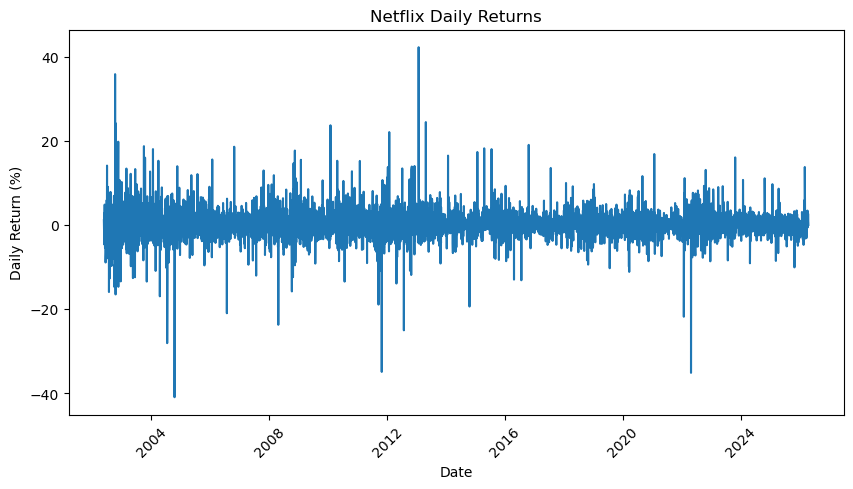

In [10]:
#Daily Return Analysis
Netflix_stock_history["Date"] = pd.to_datetime(
    Netflix_stock_history["Date"]
)

print(Netflix_stock_history["Daily_Return"].describe())

print("The cleaned dataset already contains Daily_Return. Its mean is 0.1721% and its standard deviation is 3.4372%.")

plt.figure(figsize=(10, 5))
plt.plot(
    Netflix_stock_history["Date"],
    Netflix_stock_history["Daily_Return"]
)
plt.title("Netflix Daily Returns")
plt.xlabel("Date")
plt.ylabel("Daily Return (%)")
plt.xticks(rotation=45)
plt.show()

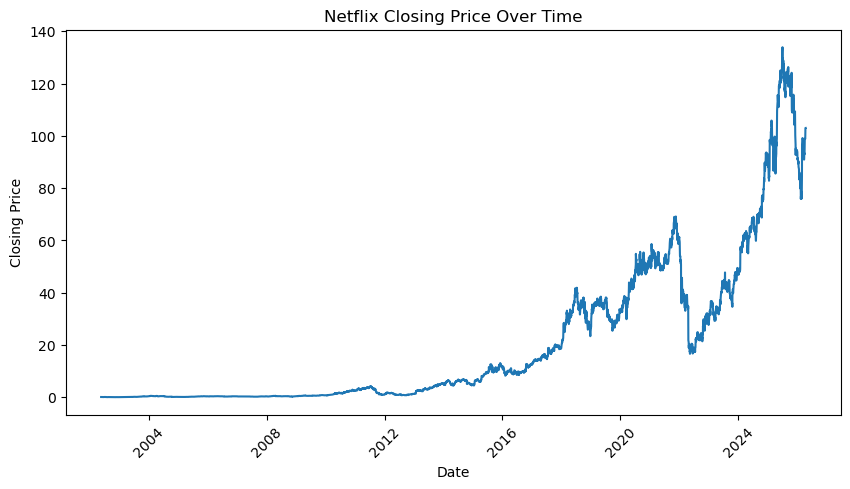

In [12]:
#Stock Price Trend
plt.figure(figsize=(10, 5))
plt.plot(
    Netflix_stock_history["Date"],
    Netflix_stock_history["Close"]
)
plt.title("Netflix Closing Price Over Time")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.xticks(rotation=45)
plt.show()

In [18]:
#Annual Performance
yearly = Netflix_stock_history.groupby("Year").agg(
    Avg_Close=("Close", "mean"),
    Max_Close=("Close", "max"),
    Min_Close=("Close", "min"),
    Avg_Volume=("Volume", "mean"),
    Volatility=("Daily_Return", "std")
)

print(yearly)

annual_return = (
    Netflix_stock_history.groupby("Year")["Close"].last()
    / Netflix_stock_history.groupby("Year")["Close"].first()
    - 1
) * 100

print(annual_return)

       Avg_Close   Max_Close  Min_Close    Avg_Volume  Volatility
Year                                                             
2002    0.085017    0.127643   0.037286  5.081364e+07    7.004979
2003    0.208120    0.425714   0.077286  1.688897e+08    4.363259
2004    0.341343    0.554714   0.134714  2.401729e+08    5.027093
2005    0.259726    0.429571   0.129000  1.063681e+08    3.123887
2006    0.369100    0.452571   0.265286  9.415647e+07    2.910377
2007    0.312393    0.410000   0.229571  1.130037e+08    2.821302
2008    0.409467    0.581429   0.256286  1.107041e+08    4.315829
2009    0.632203    0.873286   0.422000  1.152381e+08    2.856295
2010    1.682417    2.941429   0.701857  2.828111e+08    3.595745
2011    2.749372    4.267571   0.912286  4.438829e+08    4.169986
2012    1.185506    1.846429   0.768571  4.086379e+08    4.330064
2013    3.527183    5.436857   1.314429  2.744361e+08    4.100312
2014    5.749512    6.919857   4.488714  1.943816e+08    2.657011
2015    9.

           Open  High   Low  Close  Adj Close  Volume
Open       1.00  1.00  1.00   1.00       1.00   -0.31
High       1.00  1.00  1.00   1.00       1.00   -0.31
Low        1.00  1.00  1.00   1.00       1.00   -0.31
Close      1.00  1.00  1.00   1.00       1.00   -0.31
Adj Close  1.00  1.00  1.00   1.00       1.00   -0.31
Volume    -0.31 -0.31 -0.31  -0.31      -0.31    1.00


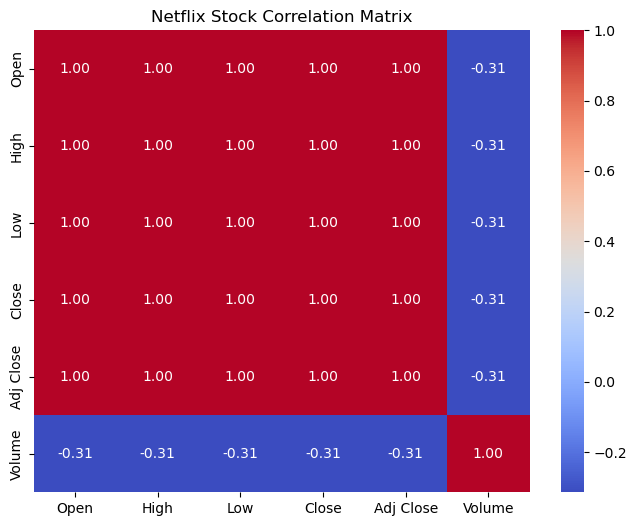

In [20]:
#Correlation Analysis
correlation = Netflix_stock_history[
    ["Open", "High", "Low", "Close", "Adj Close", "Volume"]
].corr()

print(correlation.round(2))

plt.figure(figsize=(8, 6))
sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Netflix Stock Correlation Matrix")
plt.show()

In [21]:
#10. Machine Learning
Netflix_stock_history["Lag_1"] = (
    Netflix_stock_history["Adj Close"].shift(1)
)

Netflix_stock_history["Lag_5"] = (
    Netflix_stock_history["Adj Close"].shift(5)
)

Netflix_stock_history["Lag_20"] = (
    Netflix_stock_history["Adj Close"].shift(20)
)

Netflix_stock_history["MA_5"] = (
    Netflix_stock_history["Adj Close"].rolling(5).mean()
)

Netflix_stock_history["MA_20"] = (
    Netflix_stock_history["Adj Close"].rolling(20).mean()
)

Netflix_stock_history["Target"] = (
    Netflix_stock_history["Adj Close"].shift(-1)
)

model_df = Netflix_stock_history.dropna()

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

features = [
    "Lag_1", "Lag_5", "Lag_20",
    "MA_5", "MA_20", "Volume"
]

X = model_df[features]
y = model_df["Target"]

split = int(len(model_df) * 0.80)

X_train = X.iloc[:split]
X_test = X.iloc[split:]
y_train = y.iloc[:split]
y_test = y.iloc[split:]

model = LinearRegression()
model.fit(X_train, y_train)

prediction = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, prediction))
print("RMSE:", np.sqrt(mean_squared_error(y_test, prediction)))
print("R2:", r2_score(y_test, prediction))

from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_prediction = rf_model.predict(X_test)

print("MAE:",
      mean_absolute_error(y_test, rf_prediction))

print("RMSE:",
      np.sqrt(mean_squared_error(y_test, rf_prediction)))

print("R2:",
      r2_score(y_test, rf_prediction))

MAE: 1.433416355626272
RMSE: 2.117313172769894
R2: 0.9953389583522161
MAE: 17.851818571771325
RMSE: 28.832603602895194
R2: 0.13566816930484638
